### **Import libraries**

In [72]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, confusion_matrix
from sklearn.metrics import make_scorer, balanced_accuracy_score, confusion_matrix, classification_report
import shap

from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.preprocessing import  label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from catboost import CatBoostClassifier

# warnings
import warnings
warnings.filterwarnings("ignore")

### Load the preprocessed dataset

In [2]:
# Load NSCLC gene expression dataset (GSE81089)
df = pd.read_csv("preprocessed_dataset.csv") 
labels = df["diagnosis"] # 1=squamous cell cancer, 2=AC unspecified, 3=Large cell/ NOS
gene_data = df.drop(columns=["sample_id","diagnosis","stage"])

print("Data shape: ", gene_data.shape)
gene_data.head()

Data shape:  (199, 56685)


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,RP11__415F23.4,CYP2D6.2,SNORA28,Metazoa_SRP.33,GS1__166A23.1,XXbac__BPG252P9.9,XXbac__BPGBPG55C20.1,RP11__255P5.2,MIR4787,CTC__527H23.4
0,52.1950,0.230061,43.8616,14.71010,4.81335,7.40831,112.4260,43.9196,12.12890,13.3027,...,0.215946,0.0,0.0,0.0,0.0,1.38909,0.312571,0.086774,0.0,0.000000
1,37.8891,0.086034,47.0457,7.81233,5.92073,9.83188,39.7146,60.4056,9.20525,19.6343,...,0.583569,0.0,0.0,0.0,0.0,1.15011,0.050841,0.000000,0.0,0.000000
2,23.1910,0.048022,38.1292,12.31170,8.21385,9.68575,25.9596,49.0519,23.92220,20.1660,...,0.088140,0.0,0.0,0.0,0.0,1.11998,0.551958,0.036071,0.0,0.000000
3,25.0324,0.000000,54.3030,8.41631,6.71221,10.92630,80.2073,40.4700,46.93690,20.1807,...,1.150510,0.0,0.0,0.0,0.0,4.34570,0.319958,0.000000,0.0,0.086684
4,41.9686,2.570900,51.2969,8.84999,4.79088,8.36149,38.4429,58.1048,15.60820,23.3442,...,0.946770,0.0,0.0,0.0,0.0,2.61839,0.415423,0.041381,0.0,0.095240


**Extensional Preprocessing**

Convert df["diagnosis"] to (0=squamous cell cancer, 1=AC unspecified, 2=Large cell/ NOS) matching with **LightGBM** class format which starts with 0

In [ ]:
# labels = df["diagnosis"] - 1   # 0=squamous cell cancer, 1=AC unspecified, 2=Large cell/ NOS

**Prepare training set & Testing set**

In [106]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(gene_data, labels, test_size=0.2, random_state=42, stratify=labels, shuffle=True)
print(f"Training dataset: {X_train.shape}, Testing dataset: {X_test.shape}")

Training dataset: (159, 56685), Testing dataset: (40, 56685)


### Data Imbalance Handling


In [22]:
print(f"==Original training set== \nTraining Class Distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Testing Class Distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}")

==Original training set== 
Training Class Distribution: {1: 54, 2: 86, 3: 19}
Testing Class Distribution: {1: 13, 2: 22, 3: 5}


**method I : Calculate class weights**

In [107]:
# Compute class weights based on inverse frequency
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = {cls: weight for cls, weight in zip(classes, class_weights)}
print("Class weights:", class_weights_dict)

Class weights: {1: 0.9814814814814815, 2: 0.6162790697674418, 3: 2.789473684210526}


**method II: using SMOTE to oversampling on the minor class**

In [86]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Resampled Training Shape: {X_train_res.shape}, Class Distribution: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")

Resampled Training Shape: (258, 56685), Class Distribution: {1: 86, 2: 86, 3: 86}


**method III: using downsampling on the majoirity class**

In [99]:
from imblearn.under_sampling import RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = undersampler.fit_resample(X_train, y_train)
print(f"Resampled Training Shape: {X_train_res.shape}, Class Distribution: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")

Resampled Training Shape: (57, 56685), Class Distribution: {1: 19, 2: 19, 3: 19}


### Dimensional Reduction

Principal Component Analysis (PCA)

PCA involves calculating the covariance matrix of the data, then finding the eigenvalues and eigenvectors of this matrix. The eigenvectors determine the principal components, and the eigenvalues determine their magnitude.

Training shape after PCA: (159, 25), Test shape: (40, 25)
Explained Variance Ratio: 0.9652138488713143


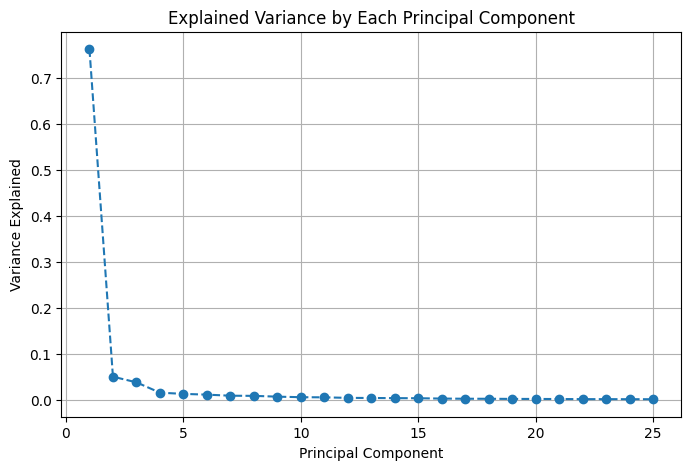

In [15]:
# Standardizing
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

num_components = 25

# Apply PCA
pca = PCA(n_components=num_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Training shape after PCA: {X_train_pca.shape}, Test shape: {X_test_pca.shape}")
print("Explained Variance Ratio:", np.sum(pca.explained_variance_ratio_))

explained_variance_ratio = pca.explained_variance_ratio_
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Explained Variance by Each Principal Component')
plt.grid(True)
plt.show()

In [150]:
# Extract component loadings (contributions of genes to each component)
pca_components = pca.fit(X_train)
components_df = pd.DataFrame(pca_components.components_, columns=gene_data.columns) 
components_df.index = [f'PC{i+1}' for i in range(num_components)]
components_df.head()

def get_top_genes_for_component(components_df, n_genes=10):
    top_genes = {}
    for component in components_df.index:
        # Get absolute values to find strongest contributions
        top_gene_indices = components_df.loc[component].abs().nlargest(n_genes).index
        top_genes[component] = top_gene_indices.tolist()
    return top_genes

# top_genes = get_top_genes_for_component(components_df)
# print("Top Contributing Genes for Each Principal Component:")
# for pc, genes in top_genes.items():
#     print(f"{pc}: {', '.join(genes)}")


def plot_top_genes_for_component(components_df, component='PC1', n_genes=10):
    top_genes = components_df.loc[component].abs().nlargest(n_genes)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_genes.values, y=top_genes.index)
    plt.xlabel('Contribution')
    plt.ylabel('Gene')
    plt.title(f'Top {n_genes} Contributing Genes for {component}')
    plt.show()

t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE minimizes the Kullback-Leibler divergence between the joint probabilities of the low-dimensional embedding and the high-dimensional data.

Training shape after t-SNE: (57, 3), Test shape: (40, 3)


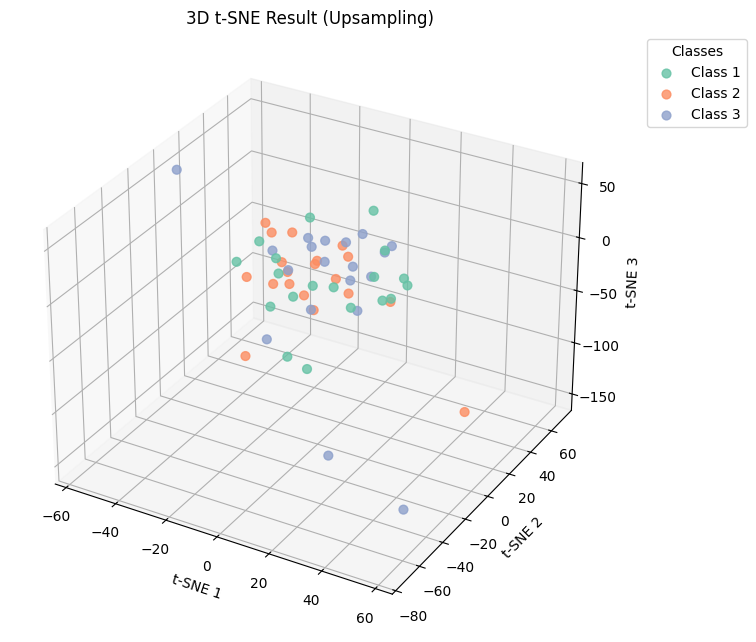

In [100]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
# Apply t-SNE
tsne = TSNE(n_components=3, perplexity=30, n_iter=300, random_state=42, init='pca')
X_train_tsne = tsne.fit_transform(X_train_res)
X_test_tsne = tsne.fit_transform(X_test)
print(f"Training shape after t-SNE: {X_train_tsne.shape}, Test shape: {X_test_tsne.shape}")

# 2D Plot the results
# X_tsne_data = np.vstack((X_train_tsne.T, y_train)).T
# df_tsne = pd.DataFrame(X_tsne_data, columns=["t-SNE component 1", "t-SNE component 2","class"])
# plt.figure(figsize=(6, 6))
# plt.title('t-SNE Result')
# sns.scatterplot(data=df_tsne, hue="class", x="t-SNE component 1", y="t-SNE component 2")
# plt.show()


# 3D Plot the results
df_tsne = pd.DataFrame(X_train_tsne, columns=["t-SNE1", "t-SNE2", "t-SNE3"])
df_tsne["label"] = y_train_res.values
fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

unique_labels = df_tsne["label"].unique()
palette = sns.color_palette("Set2", len(unique_labels))

for i, label in enumerate(unique_labels):
    subset = df_tsne[df_tsne["label"] == label]
    ax.scatter(subset["t-SNE1"], subset["t-SNE2"], subset["t-SNE3"],
               label=f"Class {label}", s=40, alpha=0.8, color=palette[i])
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.set_title("3D t-SNE Result (Upsampling)")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), title="Classes")
plt.subplots_adjust(right=0.8)  # leave space for legend
plt.show()

Uniform Manifold Approximation and Projection (UMAP)

UMAP is based on manifold theory and algebraic topology. It constructs a weighted graph to represent the data and optimizes the layout of this graph in lower dimensions.

Training shape after UMAP: (159, 3), Test shape: (40, 3)


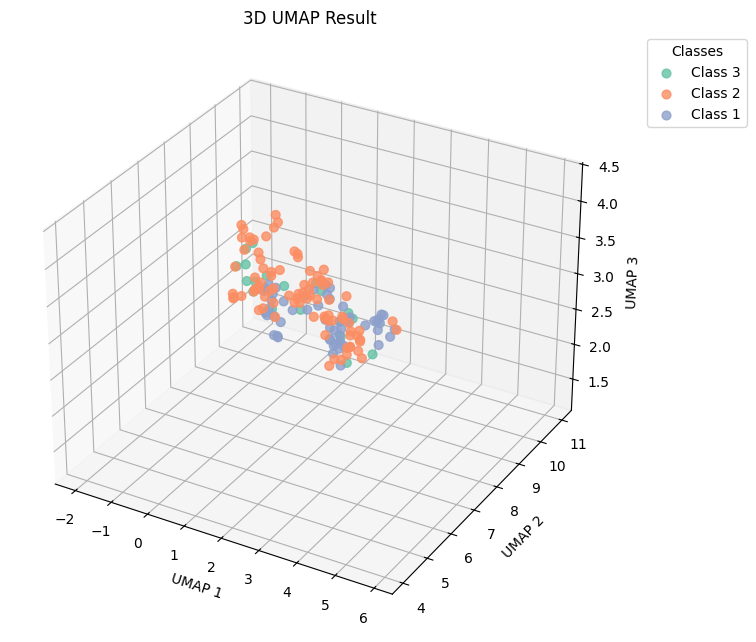

In [115]:
import umap
import umap.plot

# Apply UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, metric='euclidean', random_state=42)
X_train_umap = umap_model.fit_transform(X_train)
X_test_umap = umap_model.fit_transform(X_test)
print(f"Training shape after UMAP: {X_train_umap.shape}, Test shape: {X_test_umap.shape}")

# Plot the results
# X_umap = umap_model.fit(X_train)
# umap.plot.diagnostic(X_umap, diagnostic_type='pca')

# X_umap_data = np.vstack((X_train_umap.T, y_train)).T
# df_umap = pd.DataFrame(X_umap_data, columns=["UMAP component 1", "UMAP component 2","class"])
# plt.figure(figsize=(6, 6))
# plt.title('UMAP Result')
# sns.scatterplot(data=df_umap, hue="class", x="UMAP component 1", y="UMAP component 2")
# plt.show()

# 3D Plot the results
df_umap = pd.DataFrame(X_train_umap, columns=["UMAP1", "UMAP2", "UMAP3"])
df_umap["label"] = y_train.values
fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

unique_labels = df_umap["label"].unique()
palette = sns.color_palette("Set2", len(unique_labels))

for i, label in enumerate(unique_labels):
    subset = df_umap[df_umap["label"] == label]
    ax.scatter(subset["UMAP1"], subset["UMAP2"], subset["UMAP3"],
               label=f"Class {label}", s=40, alpha=0.8, color=palette[i])
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.set_title("3D UMAP Result")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), title="Classes")
plt.subplots_adjust(right=0.8)  # leave space for legend
plt.show()

### CatBoostClassifier

CatBoost is a high-performance open source library for gradient boosting on decision trees.

Advantages of CatBoost library are as follows:-

- Performance: CatBoost provides state of the art results and it is competitive with any leading machine learning algorithm on the performance front.
- Handling Categorical features automatically: We can use CatBoost without any explicit pre-processing to convert categories into numbers. CatBoost converts categorical values into numbers using various statistics on combinations of categorical features and combinations of categorical and numerical features.
- Robust: It reduces the need for extensive hyper-parameter tuning and lower the chances of overfitting also which leads to more generalized models. Although, CatBoost has multiple parameters to tune and it contains parameters like the number of trees, learning rate, regularization, tree depth, fold size, bagging temperature and others.
- Easy-to-use: We can use CatBoost from the command line, using an user-friendly API for both Python and R.

ref: https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier_fit

In [37]:
# Implement CatBoost Classifier
cb = CatBoostClassifier(
    random_state=42, 
    class_weights=class_weights_dict,  # comment out if using SMOTE
    l2_leaf_reg=5,  
    depth=3,  
    learning_rate=0.05,  
    bootstrap_type='Bayesian', 
    # bootstrap_type='Bernoulli', 
    # subsample=0.8,   
    iterations=300,
    verbose=0,
    eval_metric='MultiClass', 
    early_stopping_rounds=20,
    )

# Train the model
# cb.fit(X_train_pca, y_train) # comment out if using SMOTE
cb.fit(X_train_pca, y_train, eval_set=(X_test_pca, y_test),plot=False)

# Predict on test data
y_pred_train = cb.predict(X_train_pca)
y_pred_test = cb.predict(X_test_pca)

best_model = cb

# Save the model to a file (e.g., "best_model.cbm")
best_model.save_model("best_model.cbm", format="cbm")

**GridSearch**

In [116]:
x_train = X_train_umap
y_train = y_train
x_test = X_test_umap

In [121]:
# Define parameter grid
param_grid = {
    'depth': [3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [5, 7, 10],
    'iterations': [100, 200, 300],
    'bootstrap_type': ['MVS','Bayesian'],
    # 'subsample': [0.8, 1.0],
}

# Create model and GridSearchCV
cb = CatBoostClassifier(random_state=42, verbose=0, class_weights=class_weights_dict)  # remove class_weight  out if using up/down sampling
# cb = CatBoostClassifier(random_state=42, verbose=0)

# Use balanced accuracy as the evaluation metric
scorer = make_scorer(balanced_accuracy_score)

# Perform GridSearch with Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    cb,
    param_grid,
    cv=kf,
    scoring=scorer,
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(x_train, y_train)

# Get best parameters and train final model
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Best Parameters: {'bootstrap_type': 'Bayesian', 'depth': 4, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.05}


In [122]:
# Train with best parameters
best_model = CatBoostClassifier(**best_params, random_state=42, verbose=0, 
                                eval_metric='MultiClass', 
                                early_stopping_rounds=20,
                                class_weights=class_weights_dict
                                )
best_model.fit(x_train, y_train, eval_set=(x_test, y_test),plot=False)

# Save the model to a file (e.g., "best_model.cbm")
best_model.save_model(f"best_model_umap.cbm", format="cbm")

In [123]:
best_model = CatBoostClassifier()
best_model.load_model("best_model_umap.cbm")

# Predict and evaluate
y_pred_train = best_model.predict(x_train)
y_pred_test = best_model.predict(X_test)

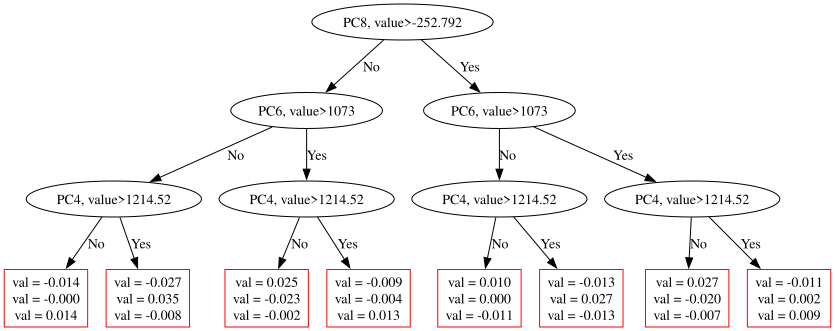

In [66]:
from catboost import Pool
# # Visualize a specific tree
best_model.plot_tree(tree_idx=0, pool=Pool(X_train_pca, y_train, feature_names=[f'PC{i+1}' for i in range(X_train_pca.shape[1])]))

Balanced Accuracy Train = 0.4873
Balanced Accuracy Test = 0.3333
Classification Report:
               precision    recall  f1-score   support

           1       0.33      1.00      0.49        13
           2       0.00      0.00      0.00        22
           3       0.00      0.00      0.00         5

    accuracy                           0.33        40
   macro avg       0.11      0.33      0.16        40
weighted avg       0.11      0.33      0.16        40



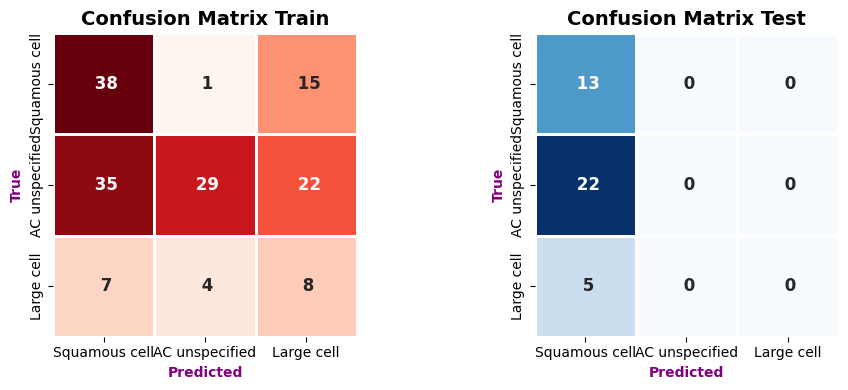

In [124]:
# Evaluation with imbalanced dataset
# Accuracy
bal_acc_train = balanced_accuracy_score(y_train, y_pred_train)  
bal_acc_test = balanced_accuracy_score(y_test, y_pred_test)
print(f"Balanced Accuracy Train = {bal_acc_train:.4f}")
print(f"Balanced Accuracy Test = {bal_acc_test:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_test))

# Confusion Matrix
label2id = {'Squamous cell':0, 'AC unspecified':1, 'Large cell':2} # 0=squamous cell cancer, 1=AC unspecified, 2=Large cell/ NOS
cf_mx_train = confusion_matrix(y_train, y_pred_train)
cf_mx_test = confusion_matrix(y_test, y_pred_test)

fig,axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))
axes = axes.flat

sns.heatmap(cf_mx_train, cmap = "Reds", annot = True, 
            fmt = " ", cbar = False, square = True, xticklabels = label2id.keys(), 
            yticklabels = label2id.keys(), linewidths = 1.0, annot_kws = {'fontsize':12, 'fontweight':'bold'}, ax = axes[0])
axes[0].set_xlabel("Predicted", fontsize = 10, fontweight = "bold", color = "purple")
axes[0].set_ylabel("True", fontsize = 10, fontweight = "bold", color = "purple")
axes[0].set_title("Confusion Matrix Train", fontsize = 14, fontweight = "bold")

sns.heatmap(cf_mx_test, cmap = "Blues", annot = True, 
            fmt = " ", cbar = False, square = True, xticklabels = label2id.keys(), 
            yticklabels = label2id.keys(), linewidths = 1.0, annot_kws = {'fontsize':12, 'fontweight':'bold'}, ax = axes[1])
axes[1].set_xlabel("Predicted", fontsize = 10, fontweight = "bold", color = "purple")
axes[1].set_ylabel("True", fontsize = 10, fontweight = "bold", color = "purple")
axes[1].set_title("Confusion Matrix Test", fontsize = 14, fontweight = "bold")

fig.tight_layout()
fig.show()

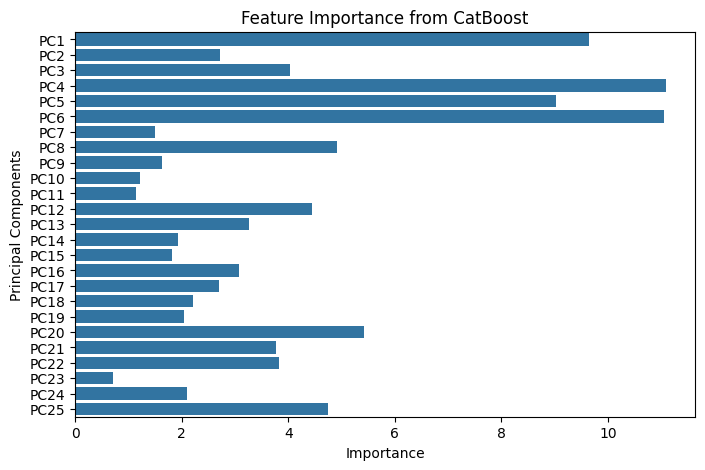

In [42]:
# Plot feature importance
feature_importances = best_model.get_feature_importance()
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances, y=[f'PC{i+1}' for i in range(len(feature_importances))])
plt.xlabel('Importance')
plt.ylabel('Principal Components')
plt.title('Feature Importance from CatBoost')
plt.show()

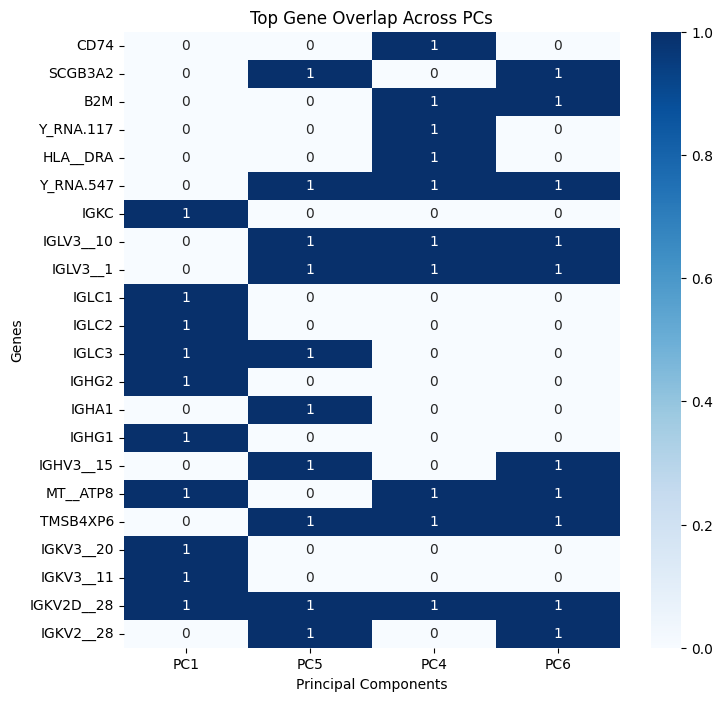

In [49]:
# Choose the top genes for specific PCs
selected_pcs = ['PC1', 'PC5', 'PC4', 'PC6']
top_n = 10

# Extract component loadings (contributions of genes to each component)
pca_components = pca.fit(X_train)
components_df = pd.DataFrame(pca_components.components_, columns=gene_data.columns) 
components_df.index = [f'PC{i+1}' for i in range(num_components)]
components_df.head()

# Extract top contributing genes for each PC
top_genes_df = pd.DataFrame(0, index=X_train.columns, columns=selected_pcs)
for pc in selected_pcs:
    top_genes = components_df.loc[pc].abs().nlargest(top_n).index
    top_genes_df.loc[top_genes, pc] = 1

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(top_genes_df.loc[top_genes_df.sum(axis=1) > 0], cmap='Blues', annot=True)
plt.title('Top Gene Overlap Across PCs')
plt.xlabel('Principal Components')
plt.ylabel('Genes')
plt.show()

Explanation:
- Heatmap: Blue cells show where a gene is a top contributor for a PC.
- Annotated: The matrix is labeled with 1 for contribution and 0 for no contribution.
- Filtered: Only genes with at least one contribution are shown.

**SHAP**

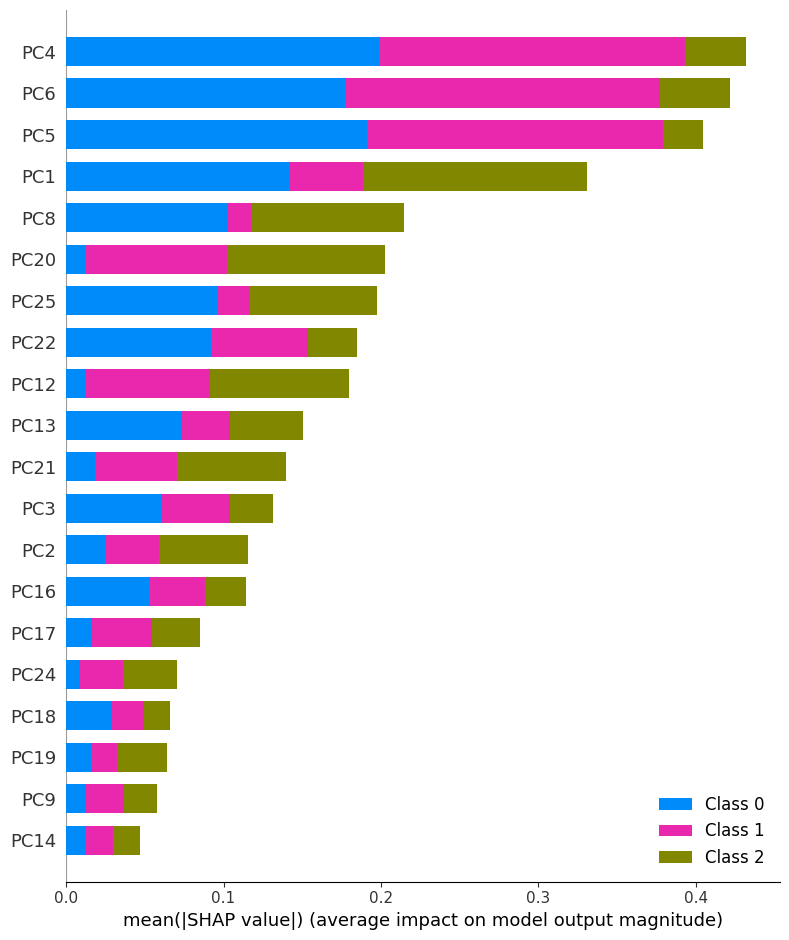

Top 3 Biomarker Candidates (PCA Components) in Order of Importance: [3 5 4]
PC4: Mean SHAP Value = 0.1439
PC6: Mean SHAP Value = 0.1406
PC5: Mean SHAP Value = 0.1349


In [ ]:
gene_names = gene_data.columns
# SHAP Interpretation
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_train_pca)

# Visualize SHAP values for the top 3 PCA components
shap.summary_plot(shap_values, X_train_pca, feature_names=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])

# Calculate mean absolute SHAP values for each PCA component
mean_abs_shap = np.abs(shap_values.values).mean(axis=(0, 2))

top_features_indices = np.argsort(mean_abs_shap)[-3:][::-1]
print("Top 3 Biomarker Candidates (PCA Components) in Order of Importance:", top_features_indices)
for i, idx in enumerate(top_features_indices):
    print(f"PC{idx+1}: Mean SHAP Value = {mean_abs_shap[idx]:.4f}")

Sample: 2


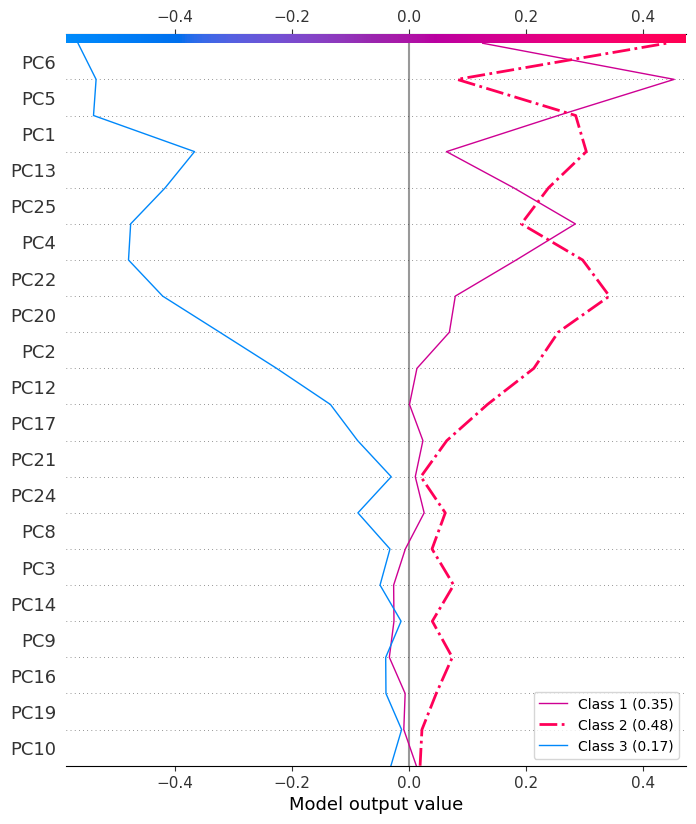

In [116]:
# Ensure base_values matches the number of classes and convert to a list
base_values = explainer.expected_value

# Calculate SHAP values (multi-class output)
shap_values_list = explainer.shap_values(X_train_pca)
# Convert (159, 25, 3) to (3, 159, 25)
shap_values_list = np.transpose(shap_values_list, (2, 0, 1))
# Convert to a list of arrays for each class
shap_values_list = [shap_values_list[i].tolist() for i in range(shap_values_list.shape[0])]
# print(f"Converted SHAP values shape: {len(shap_values_list)}, {len(shap_values_list[0])}, {len(shap_values_list[0][0])}")

# Select a specific sample (row)
row_index = 2
print(f"Sample: {row_index}")

# Get class probabilities instead of class labels
y_pred_proba_train = best_model.predict_proba(X_train_pca)

# Helper function to create class labels
def class_labels(row_index):
    return [f"Class {i + 1} ({y_pred_proba_train[row_index][i]:.2f})" for i in range(len(base_values))]

# Plot Multioutput Decision Plot
shap.multioutput_decision_plot(
    base_values,
    shap_values_list,
    row_index=row_index,
    feature_names=[f'PC{i+1}' for i in range(X_train_pca.shape[1])],
    highlight=[np.argmax(y_pred_proba_train[row_index])],
    legend_labels=class_labels(row_index),
    legend_location="lower right",
)

Beeswarm Plot for Class 0


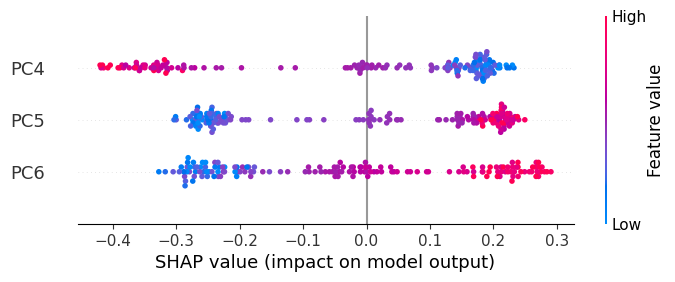

Beeswarm Plot for Class 1


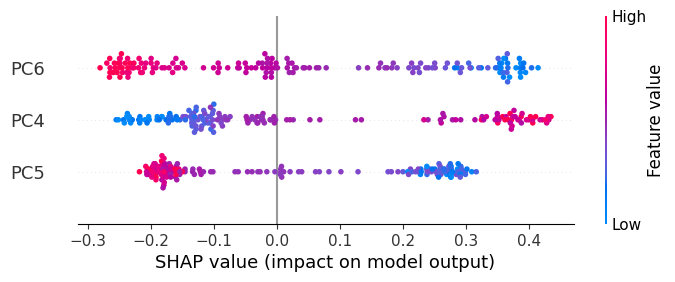

Beeswarm Plot for Class 2


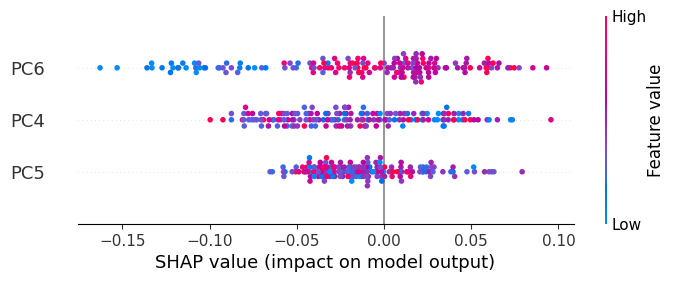

In [ ]:
# SHAP Beeswarm plot for the top 3 PCA components for each class
for class_idx in range(shap_values.values.shape[2]):
    print(f"Beeswarm Plot for Class {class_idx}")
    shap.plots.beeswarm(shap.Explanation(
        values=shap_values.values[:, top_features_indices, class_idx],
        base_values=shap_values.base_values[:, class_idx],
        data=X_train_pca[:, top_features_indices],
        feature_names=[f'PC{i+1}' for i in top_features_indices]
    ))

In [ ]:
# Summary plot of SHAP values for formula raw predictions for class 0
shap.plots.beeswarm(shap_values[..., 0])

In [ ]:
# Summary plot of SHAP values for formula raw predictions for class 1
shap.plots.beeswarm(shap_values[..., 1])

In [ ]:
# Summary plot of SHAP values for formula raw predictions for class 2
shap.plots.beeswarm(shap_values[..., 2])

In [46]:
# Get the gene names and contributions
gene_names = gene_data.columns
gene_contributions = pca.components_.T

# Get top 3 PCA components identified from SHAP
top_pcs = top_features_indices
print("Top 3 PCA Components from PCA:")

# Find the genes with the highest absolute contribution to each component
top_genes_per_pc = {}
for pc in top_pcs:
    top_genes_idx = np.argsort(np.abs(gene_contributions[:, pc]))[::-1][:10]  # Top 10 genes
    top_genes_per_pc[f'{pc+1}'] = [gene_names[i] for i in top_genes_idx]  # gene_names = list of gene labels

for pc, genes in top_genes_per_pc.items():
    print(f"PC{pc} Top Contributing Genes (Potential Biomarkers): {genes}")


Top 3 PCA Components from PCA:
PC4 Top Contributing Genes (Potential Biomarkers): ['Y_RNA.547', 'TMSB4XP6', 'B2M', 'Y_RNA.117', 'IGLV3__10', 'CD74', 'IGKV2D__28', 'HLA__DRA', 'MT__ATP8', 'IGLV3__1']
PC6 Top Contributing Genes (Potential Biomarkers): ['Y_RNA.547', 'SCGB3A2', 'TMSB4XP6', 'IGLV3__10', 'IGLV3__1', 'B2M', 'IGKV2D__28', 'MT__ATP8', 'IGHV3__15', 'IGKV2__28']
PC5 Top Contributing Genes (Potential Biomarkers): ['Y_RNA.547', 'IGLV3__10', 'IGLV3__1', 'IGKV2D__28', 'IGLC3', 'TMSB4XP6', 'SCGB3A2', 'IGKV2__28', 'IGHV3__15', 'IGHA1']


**Interpret Biomarkers for Each Class using SHAP**

Ogcogenes ref: 
- El-Telbany A, Ma PC. Cancer genes in lung cancer: racial disparities: are there any? Genes Cancer. 2012 Jul;3(7-8):467-80. doi: 10.1177/1947601912465177. PMID: 23264847; PMCID: PMC3527990. https://pmc.ncbi.nlm.nih.gov/articles/PMC3527990/#section2-1947601912465177

In [47]:
# SHAP values for each class
genes_set = []
for class_idx in range(shap_values.values.shape[2]):
    print(f"\nClass {class_idx+1} Top Biomarkers:")
    shap_values_class = np.abs(shap_values.values[:, :, class_idx]).mean(axis=0)
    top_genes_idx = np.argsort(shap_values_class)[-10:][::-1]  # Top 10 genes
    top_genes = [gene_names[i] for i in top_genes_idx]
    genes_set.append(set(top_genes))
    print(f"Top Genes: {top_genes}")
    
    # Ogcogene
    oncogenes = ["EGFR", "KRAS", "MET", "LKB1", "BRAF", "PIK3CA", "ALK", "RET", "ROS1"]
    print(f"Containing Oncogenes: {([gene for gene in top_genes if gene in oncogenes])}")



Class 1 Top Biomarkers:
Top Genes: ['SCYL3', 'C1orf112', 'FGR', 'TSPAN6', 'FUCA2', 'HS3ST1', 'BAD', 'LAS1L', 'DPM1', 'CFTR']
Containing Oncogenes: []

Class 2 Top Biomarkers:
Top Genes: ['FGR', 'SCYL3', 'C1orf112', 'RAD52', 'NIPAL3', 'BAD', 'MYH16', 'TSPAN6', 'DPM1', 'ANKIB1']
Containing Oncogenes: []

Class 3 Top Biomarkers:
Top Genes: ['TSPAN6', 'RAD52', 'FUCA2', 'NIPAL3', 'HS3ST1', 'MYH16', 'TNMD', 'LAS1L', 'FGR', 'SCYL3']
Containing Oncogenes: []


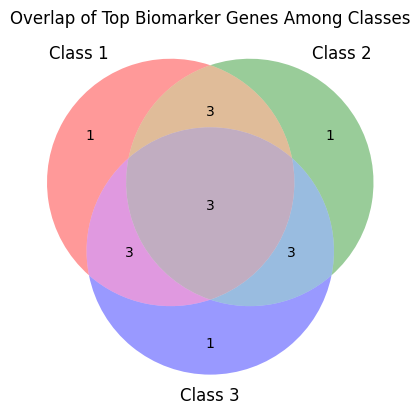

Unique to Class 0: {'CFTR'}
Unique to Class 1: {'ANKIB1'}
Unique to Class 2: {'TNMD'}
Intersection of All Classes: {'TSPAN6', 'FGR', 'SCYL3'}
Set of All Genes: {'SCYL3', 'NIPAL3', 'HS3ST1', 'CFTR', 'C1orf112', 'BAD', 'FGR', 'MYH16', 'DPM1', 'TNMD', 'FUCA2', 'TSPAN6', 'RAD52', 'LAS1L', 'ANKIB1'}


In [48]:
from matplotlib_venn import venn3

venn3(genes_set, ('Class 1', 'Class 2', 'Class 3'))
plt.title("Overlap of Top Biomarker Genes Among Classes")
plt.show()

# Find non-overlapping genes for each class
unique_to_class_0 = genes_set[0] - genes_set[1] - genes_set[2]
unique_to_class_1 = genes_set[1] - genes_set[0] - genes_set[2]
unique_to_class_2 = genes_set[2] - genes_set[0] - genes_set[1]

print("Unique to Class 0:", unique_to_class_0)
print("Unique to Class 1:", unique_to_class_1)
print("Unique to Class 2:", unique_to_class_2)
print("Intersection of All Classes:", genes_set[0] & genes_set[1] & genes_set[2])
print("Set of All Genes:", genes_set[0] | genes_set[1] | genes_set[2])

- C1ORF112 has also been shown to have altered levels of expression in some tumours with mutant TP53. Recent screens associate C1ORF112 with DNA replication and reveal possible links to DNA damage repair pathways, including the Fanconi anaemia pathway and homologous recombination. 

(cite: Edogbanya, J., Tejada-Martinez, D., Jones, N. J., Jaiswal, A., Bell, S., Cordeiro, R., van Dam, S., Rigden, D. J., & de Magalhães, J. P. (2021). Evolution, structure and emerging roles of C1ORF112 in DNA replication, DNA damage responses, and cancer. Cellular and molecular life sciences : CMLS, 78(9), 4365–4376. https://doi.org/10.1007/s00018-021-03789-8)

- TNMD, This gene encodes a protein that is related to chondromodulin-I, which is a cartilage-specific glycoprotein that functions to stimulate chondrocyte growth and to inhibit tube formation of endothelial cells. This protein is also an angiogenesis inhibitor. Genetic variation in this gene is associated with a risk for type 2 diabetes, central obesity and serum levels of systemic immune mediators in a body size-dependent manner.

(cite: https://www.ncbi.nlm.nih.gov/gene/64102)

### LightGBM

LightGBM (Light Gradient Boosting Machine) is an open-source gradient boosting framework developed by Microsoft. It is designed for efficiency and speed, particularly in handling large datasets with high-dimensional features. LightGBM is widely used for machine learning tasks, including classification, regression, and ranking.

Key Features of LightGBM:
1. Gradient-Based One-Side Sampling (GOSS) – Prioritizes important data points while reducing the size of the dataset, improving training efficiency.
2. Exclusive Feature Bundling (EFB) – Groups mutually exclusive features to reduce memory usage and speed up computation.
3. Histogram-Based Learning – Bins continuous features into discrete values, reducing computation complexity.
4. Efficient Handling of Large Datasets – Optimized for parallel and GPU processing.
5. Lower Memory Usage – Uses a more compact representation of data than other boosting frameworks like XGBoost.
6. Supports Categorical Features – Handles categorical variables natively without one-hot encoding.

Use Cases:
- Predictive modeling in finance (e.g., fraud detection, credit scoring)
- Recommendation systems
- Click-through rate (CTR) prediction in advertising
- Medical diagnosis and genomic analysis


**Training**

In [ ]:
# Convert to LightGBM dataset
train_data = lgb.Dataset(X_train_pca, label=y_train)
test_data = lgb.Dataset(X_test_pca, label=y_test, reference=train_data)

In [ ]:
# Define parameters for LightGBM
params = {
    'boosting_type': 'gbdt',
    'num_leaves': 15,
    'max_depth': 5,
    'learning_rate': 0.1,
    'objective': 'multiclass',
    'num_class': 3,
    'is_unbalance': True,
    'class_weights': class_weights,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'min_data_in_leaf': 20,
    'metric': 'multi_logloss'
}
    
# Train model
model = lgb.train(params, train_data, num_boost_round=10)

# Feature Importance
lgb.plot_importance(model, max_num_features=20)

**Shap Interpretation**

ref: Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. In I. Guyon, U. V. Luxburg, S. Bengio, H. Wallach, R. Fergus, S. Vishwanathan, & R. Garnett (Eds.), *Advances in neural information processing systems 30* (pp. 4765–4774). Curran Associates, Inc. [Paper link](http://papers.nips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions.pdf)

In [ ]:
# SHAP explanation
model = cb
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_pca)

# Summary plot
shap.summary_plot(shap_values, X_test_pca, class_names=["Squamous Cell", "AC Unspecified", "Large Cell/NOS"])

**Evaluation**

In [ ]:
# Convert probabilities to predicted classes
y_pred = model.predict(X_test_pca)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get the predicted class

# Precision & Recall
precision = precision_score(y_test, y_pred_classes, average=None)  # Per-class precision
recall = recall_score(y_test, y_pred_classes, average=None)  # Per-class recall

print("Precision per class:", precision)
print("Recall per class:", recall)

# Binarize labels for ROC computation (One-vs-Rest strategy)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Modify class labels accordingly
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC AUC
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line for reference
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Multiclass Classification")
plt.legend(loc="lower right")
plt.show()

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-v1.1")
model = AutoModel.from_pretrained("dmis-lab/biobert-v1.1")

# Tokenize the gene expression data (text format)
inputs = tokenizer(gene_texts, return_tensors="pt", padding=True, truncation=True)

# Pass the data through BioBERT to get embeddings
with torch.no_grad():
    outputs = model(**inputs)

# Use mean pooling of the last hidden state for embeddings
embeddings = outputs.last_hidden_state.mean(dim=1)

# Now, `embeddings` contains a vector representation for each sample
print(embeddings.shape)

## PCA + UMAP + CatBoost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, balanced_accuracy_score
from catboost import CatBoostClassifier
import umap

# === Step 1: Load your gene expression dataset ===
# X = X_train
# y = y_train

# === Step 2: Create a custom UMAP transformer ===
class UMAPTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=10, n_neighbors=15, min_dist=0.1, random_state=42):
        self.n_components = n_components
        self.n_neighbors = n_neighbors
        self.min_dist = min_dist
        self.random_state = random_state

    def fit(self, X, y=None):
        self.reducer_ = umap.UMAP(
            n_components=self.n_components,
            n_neighbors=self.n_neighbors,
            min_dist=self.min_dist,
            random_state=self.random_state
        )
        self.reducer_.fit(X)
        return self

    def transform(self, X):
        return self.reducer_.transform(X)

# === Step 3: Create pipeline: PCA → UMAP → CatBoost ===
pipeline = Pipeline([
    ('pca', PCA(random_state=42)),
    ('umap', UMAPTransformer()),
    ('catboost', CatBoostClassifier(verbose=0, random_state=42, class_weights=class_weights_dict))
])

# === Step 4: Define parameter grid for GridSearchCV ===
param_grid = {
    'pca__n_components': [100],
    'umap__n_components': [5, 10],
    'umap__n_neighbors': [15, 30],
    'umap__min_dist': [0.1, 0.5],
    'catboost__learning_rate': [0.03, 0.1],
    'catboost__depth': [4, 6],
}

# === Step 5: Split data and run grid search ===
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# === Step 6: Evaluate best model ===
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Params:", grid_search.best_params_)
print("Test Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 32 candidates, totalling 96 fits


/opt/anaconda3/envs/clinical_ai/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/clinical_ai/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/clinical_ai/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/clinical_ai/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/clinical_ai/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 

Best Params: {'catboost__depth': 6, 'catboost__learning_rate': 0.1, 'pca__n_components': 100, 'umap__min_dist': 0.5, 'umap__n_components': 10, 'umap__n_neighbors': 10}
Test Accuracy: 0.4233100233100233
Classification Report:
               precision    recall  f1-score   support

           1       0.47      0.62      0.53        13
           2       0.67      0.45      0.54        22
           3       0.12      0.20      0.15         5

    accuracy                           0.47        40
   macro avg       0.42      0.42      0.41        40
weighted avg       0.54      0.47      0.49        40

